In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from corner import corner

In [ ]:
posterior_files = ['/g/data/cm25/yq5547/notebooks/meraxes_emulator/gadi_run/output_10param/chains/equal_weighted_post.txt',
                  '/g/data/cm25/yq5547/dragons/programs/emulator_runs/ultranest_output_vec_P/chains/equal_weighted_post.txt',
                  '/g/data/cm25/yq5547/dragons/programs/emulator_runs/ultranest_output_U/chains/equal_weighted_post.txt']

posterior_meraxes = np.loadtxt(posterior_files[0], skiprows=1)
posterior_p = np.loadtxt(posterior_files[1], skiprows=1)
posterior_u = np.loadtxt(posterior_files[2], skiprows=1)

labels = [
        r"$\alpha_{\rm SF}$", 
        r"$\Sigma_{\rm SF,crit}$", 
        r"$\epsilon_{\rm ej}$", 
        r"$\gamma_{\rm ej}$", 
        r"$\delta_{\rm ej}$", 
        r"$\epsilon_{\rm rh}$", 
        r"$\epsilon_{\rm rh,lim}$", 
        r"$\gamma_{\rm rh}$", 
        r"$\delta_{\rm rh}$", 
        r"$\gamma_{\rm reinc}$"]

PARAMETER_BOUNDS = [(-4,0),
                    (-3,1),
                    (-5,2),
                    (-5,5),
                    (-5,5),
                    (-3,4),
                    (-3,2),
                    (-5,5),
                    (-5,5),
                    (-3,0)]

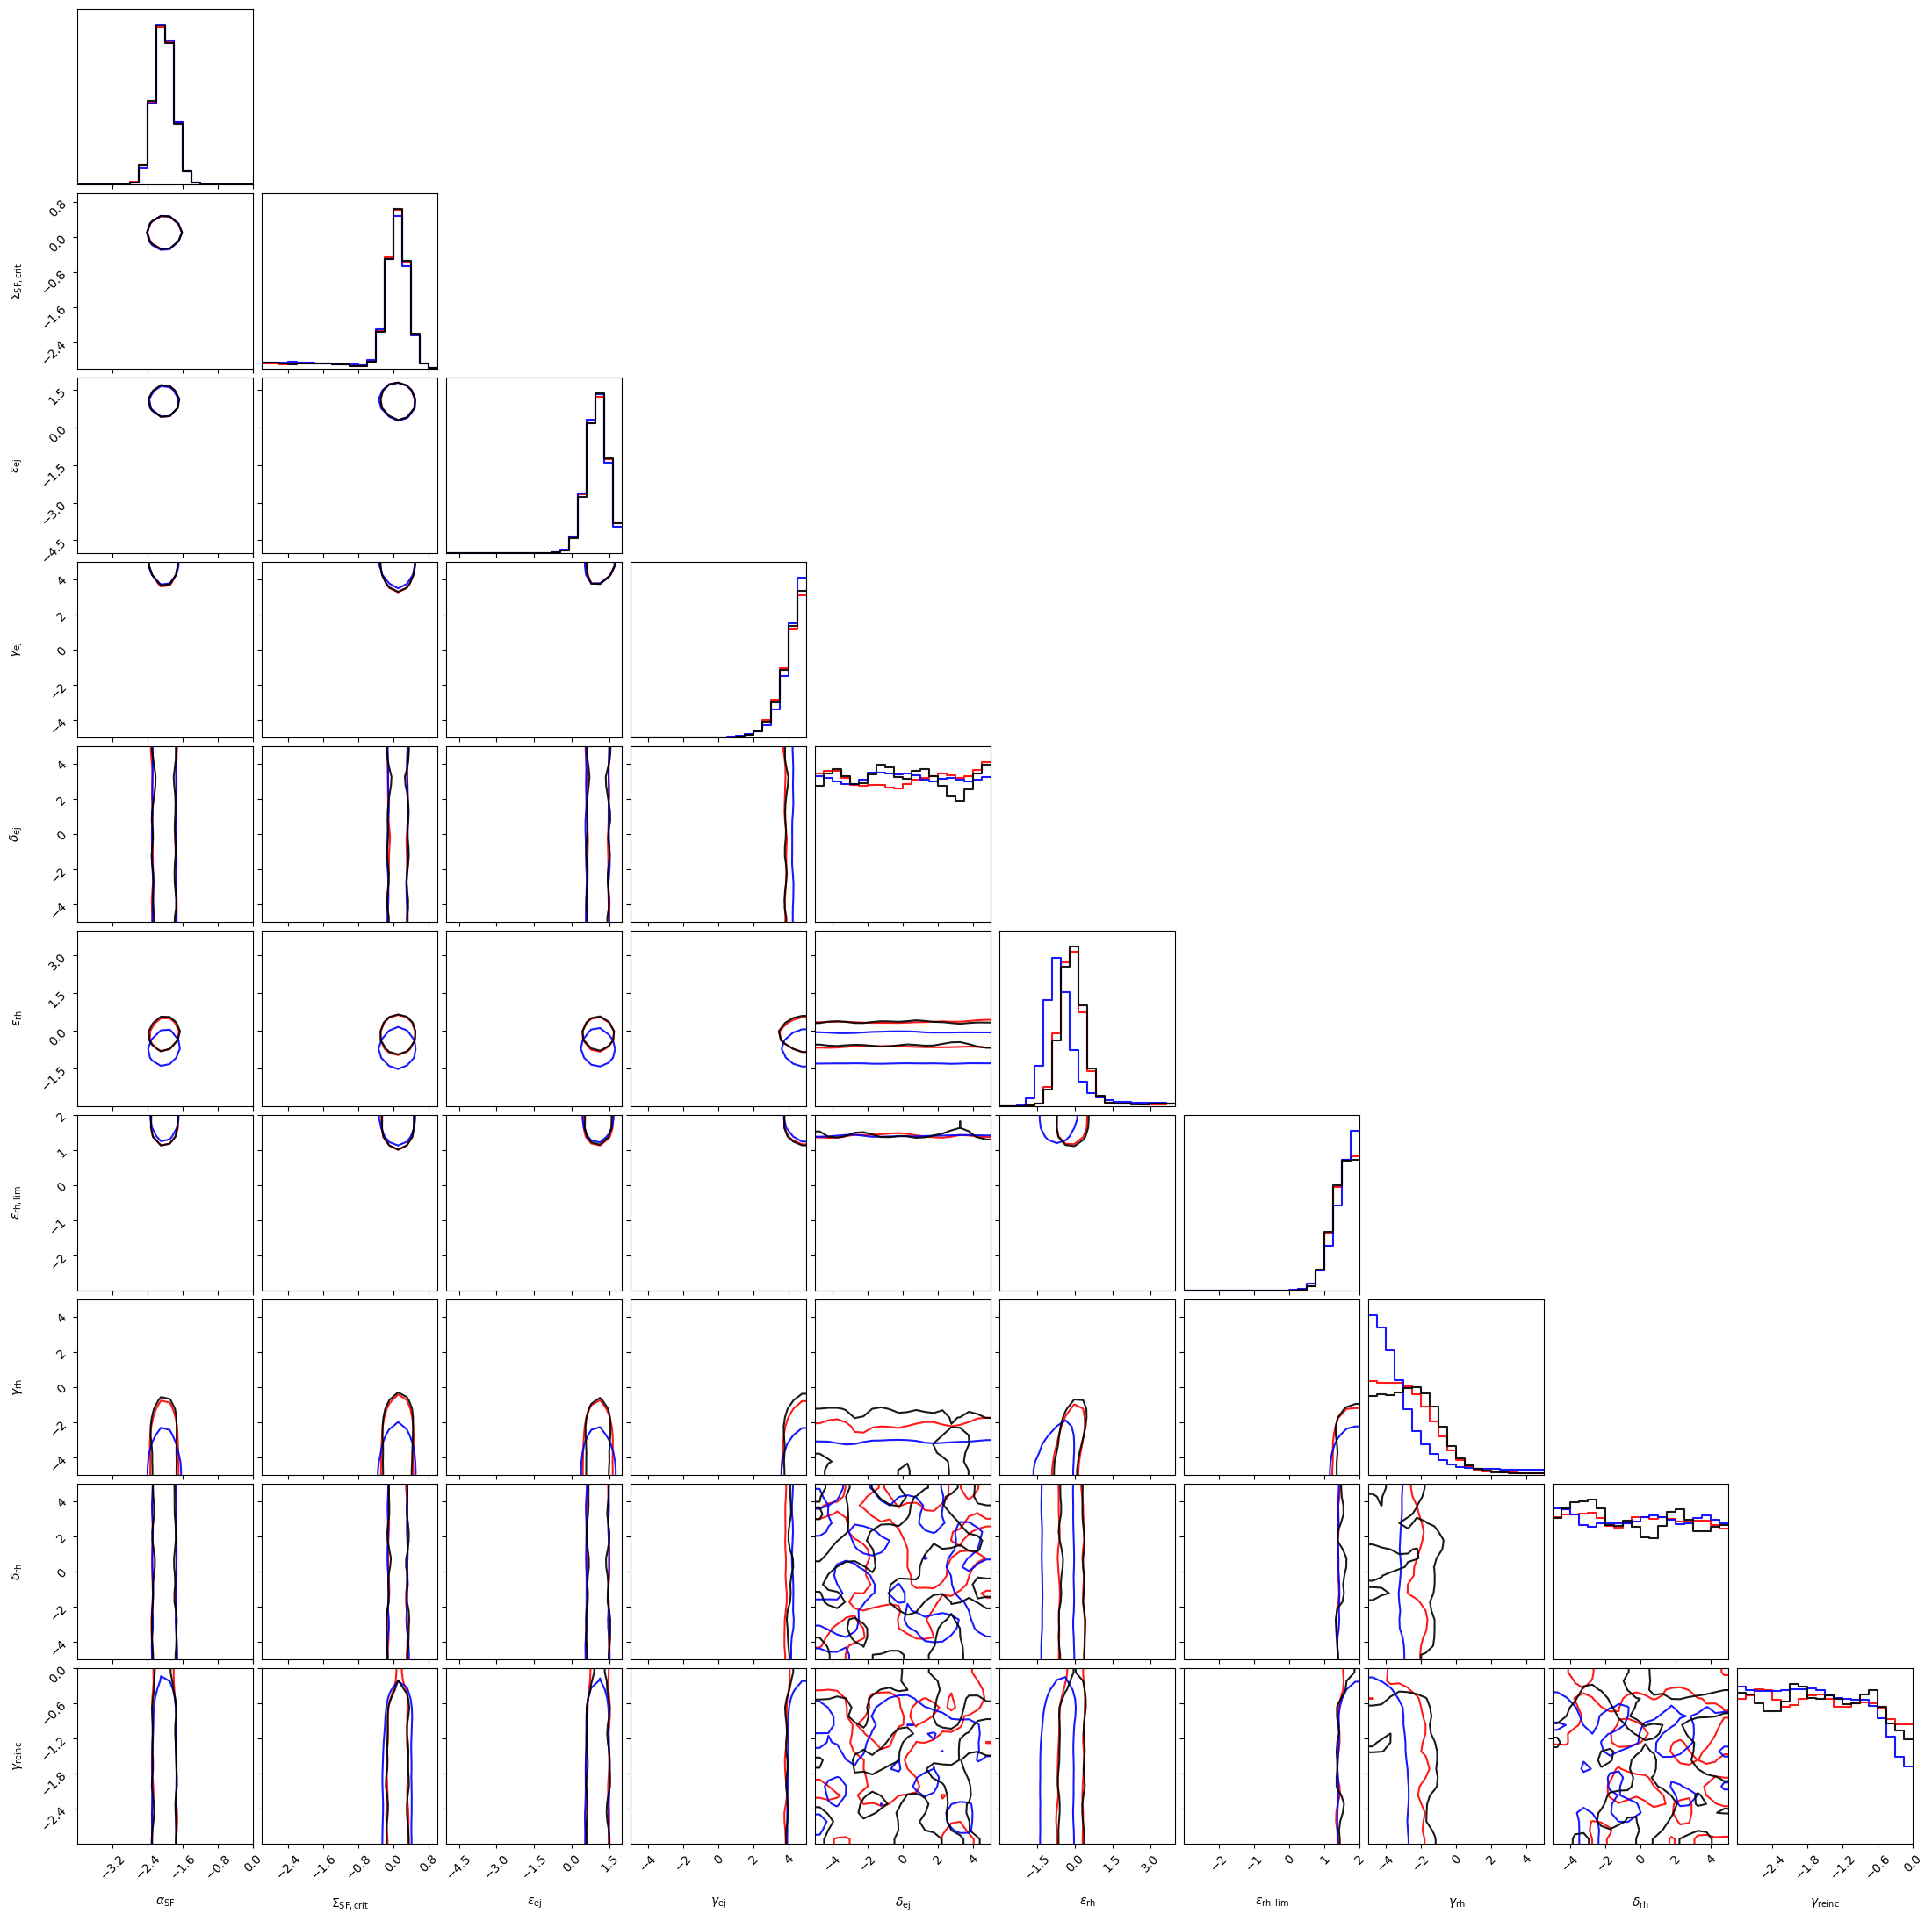

In [30]:
fig = None
for posterior, color, label in [
    (posterior_p, 'r', 'P'),
    (posterior_u, 'b', 'U'),
    (posterior_meraxes, 'k', 'Meraxes'),
]:
    fig = corner(
        posterior,
        fig=fig,
        labels=labels,
        range=PARAMETER_BOUNDS,
        smooth=1.,
        smooth1d=1.,
        levels=[0.68],
        color=color,
        weights=np.ones(len(posterior)) * len(posterior_meraxes) / len(posterior),
        plot_datapoints=False,
        plot_density=False,
        fill_contours=False,
        plot_contours=True,
        quantiles=None,
        contour_kwargs={'alpha': 0.9},
        hist_kwargs={'alpha': 0.9},
    )

plt.show()